In [34]:
from lmfit import Model, Parameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.colors import LogNorm
from astropy.visualization import simple_norm
from scipy.interpolate import interp1d
from pathlib import Path
import glob

from typing import Union


from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h = 0.7
cosmo = FlatLambdaCDM(H0=h*100, Om0=0.3)

# Function for calculating 1 Mpc corresondance of cluster redshift

In [46]:
def mpc_to_pixels(z, pixel_scale_arcsec=0.3, physical_mpc=1.0):
    arcsec_per_kpc = cosmo.arcsec_per_kpc_proper(z).value  # arcsec/kpc
    arcsec_per_mpc = arcsec_per_kpc * 1000  # arcsec/Mpc
    pixels_per_mpc = arcsec_per_mpc / pixel_scale_arcsec
    return pixels_per_mpc * physical_mpc 

# Function for loading prodiles

In [47]:

def load_profiles_real_clusters(
    outdir,
    cluster_id: Union[str, list, None] = None,
    filter: Union[str, list, None] = None,
    prefix: Union[str, list, None] = None,
    mask_filter: Union[str, list, None] = None,
    mask_prefix: Union[str, list, None] = None,
    profile_filter: Union[str, list, None] = None,
    other_prefix: Union[str, list, None] = None,
):
    def matches(value, candidate):
        if value is None:
            return True
        elif isinstance(value, list):
            return candidate in value
        else:
            return candidate == value

    profiles = []
    result_dir = Path(outdir) / cluster_id / "autoprof_results"

    for prof_path in result_dir.glob("*.prof"):
        parts = prof_path.stem.split("_")

        if len(parts) < 6:
            print(f"[SKIPPED] Too few parts: {prof_path.name}")
            continue

        try:
            # First 3 = cluster_id
            current_cluster_id = "_".join(parts[:3])
            remaining = parts[3:]

            current_filter = remaining[0]
            current_mask_filter = remaining[1]
            current_profile_filter = remaining[2]

            # Optional 
            current_mask_prefix = remaining[3] if len(remaining) > 3 else None
            current_other_prefix = remaining[4] if len(remaining) > 4 else None

            # Combining prefix from part 3 & 4 if needed (after cluster_id)
            current_prefix = "_".join(remaining[:2]) if len(remaining) >= 2 else None

        except Exception as e:
            print(f"[SKIPPED] Error parsing {prof_path.name}: {e}")
            continue

        print(f"\n {prof_path.name}")
        print(f"Parsed → cluster_id={current_cluster_id}, filter={current_filter}, mask_filter={current_mask_filter}, profile_filter={current_profile_filter}")
        print(f"Match → cluster_id={cluster_id}, filter={filter}, mask_filter={mask_filter}, profile_filter={profile_filter}")

        if not (
            matches(cluster_id, current_cluster_id) and
            matches(filter, current_filter) and
            matches(prefix, current_prefix) and
            matches(mask_filter, current_mask_filter) and
            matches(mask_prefix, current_mask_prefix) and
            matches(profile_filter, current_profile_filter) and
            matches(other_prefix, current_other_prefix)
        ):
            continue

        try:
            df = pd.read_csv(prof_path, skiprows=1)
            label = prof_path.stem
            profiles.append((label, df))
        except Exception as e:
            print(f"[ERROR] Could not read {prof_path}: {e}")

    profiles.sort(key=lambda x: x[0])
    return profiles



# Function for extracting Rmax

In [37]:
def extract_rmax_crossing(
    sb_r=None, sb_flux=None,
    noise_r=None, noise_flux=None,
    use_profiles=False,
    sb_profile=None, noise_profile=None,
    method="annulus",
    max_crossings=1
):
    from scipy.interpolate import interp1d
    import numpy as np

    if use_profiles:
        if sb_profile is None or noise_profile is None:
            raise ValueError("sb_profile and noise_profile must be provided when use_profiles=True.")

        if method == "annulus":
            sb_r = sb_profile["SMA_annulus_centre"].values
            sb_flux = sb_profile["Median_flux_annulus"].values
        elif method == "isophote":
            sb_r = sb_profile["R"].values
            sb_flux = sb_profile["I"].values
        else:
            raise ValueError("Invalid method. Choose 'annulus' or 'isophote'.")

        noise_r = noise_profile["SMA_annulus_centre_arcsec"].values
        noise_flux = 3 * noise_profile["MAD_Median_Clipped_Flux"].values

    # Clean zero or invalid 
    
    sb_flux = np.where(sb_flux == 0, np.nan, sb_flux)

    # Interpolating noise to flux radii
    interp_noise = interp1d(noise_r, noise_flux, kind='linear', fill_value="extrapolate")
    noise_interp = interp_noise(sb_r)

    diff = sb_flux - noise_interp

    crossings = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

    if len(crossings) == 0:
        return None

    crossing_radii = []

    for idx in crossings[:max_crossings]:
        r1, r2 = sb_r[idx], sb_r[idx + 1]
        f1, f2 = sb_flux[idx], sb_flux[idx + 1]
        n1, n2 = noise_interp[idx], noise_interp[idx + 1]

        denominator = (f2 - f1) - (n2 - n1)
        if np.abs(denominator) < 1e-10 or np.isnan(denominator):
            continue

        crossing_radius = r1 + (r2 - r1) * (n1 - f1) / denominator
        crossing_radii.append(crossing_radius)

    if len(crossing_radii) == 0:
        return None
    else:
        return crossing_radii[0] if max_crossings == 1 else crossing_radii


def plot_sb_profiles(
    profiles=None,
    pixelscale=0.3,
    rad_output_unit='arcsec',
    cosmology=None,
    redshift=None,
    specific_labels=None,
    xlog=True,
    ylog=True,
    ax=None,
    savefig=False,
    outdir=None,
    style_dict=None,
    legendloc='lower left',
    legendfontsize=10,
    fluxtype='flux',
    noise_profile=None,
    extract_rmax=False,
    extract_rmax_labels=None,
    rmax_label_prefix='Rmax'
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    if style_dict is None:
        style_dict = {}

    allowed_labels = set(specific_labels) if specific_labels else None
    extract_rmax_labels = set(extract_rmax_labels) if extract_rmax_labels else set()

    # Unit conversion
    if rad_output_unit == 'pix':
        scale_conversion = 1 / pixelscale
    elif rad_output_unit == 'arcsec':
        scale_conversion = 1
    elif rad_output_unit == 'kpc':
        if cosmology is None or redshift is None:
            raise ValueError("Cosmology and redshift must be provided for kpc conversion.")
        scale_conversion = 1 / cosmology.arcsec_per_kpc_proper(redshift).value
    else:
        raise ValueError(f"Unsupported rad_output_unit: {rad_output_unit}")

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fallback_index = 0

    def extract_prefix(label):
        parts = label.split("_")
        if len(parts) >= 7:
            return "_".join(parts[2:4])
        return label

    def get_style(label):
        nonlocal fallback_index 
        prefix = extract_prefix(label)
        base_style = {
            'color': color_cycle[fallback_index % len(color_cycle)],
            'linestyle': '-',
            'marker': 'o',
            'label': label
        }
        if label in style_dict:
            return {**base_style, **style_dict[label]}
        if prefix in style_dict:
            return {**base_style, **style_dict[prefix]}
        fallback_index += 1
        return base_style

    if profiles:
        for item in profiles:
            if isinstance(item, tuple) and len(item) == 2:
                label, prof = item
            else:
                raise ValueError("Each item in 'profiles' must be a (label, DataFrame) tuple")

            if allowed_labels and label not in allowed_labels:
                continue

            style = get_style(label)
            base_label = style.get('label', label)
            method_used = None

            # Isophote
            if 'R' in prof and 'I' in prof:
                method_used = 'isophote'
                fluxaxis = 23.9 - 2.5 * np.log10(prof['I']) if fluxtype == 'mag' else prof['I']
                ax.plot(
                    prof['R'] * scale_conversion,
                    fluxaxis,
                    label=f"Isophote - {base_label}",
                    **{k: style[k] for k in ['color', 'linestyle', 'marker']},
                    markersize=2,
                    linewidth=0.5,
                    alpha=0.8
                )

            # Annulus
            if 'SMA_annulus_centre' in prof and 'Median_flux_annulus' in prof:
                method_used = 'annulus'
                fluxaxis = 23.9 - 2.5 * np.log10(prof['Median_flux_annulus']) if fluxtype == 'mag' else prof['Median_flux_annulus']
                ax.plot(
                    prof['SMA_annulus_centre'] * scale_conversion,
                    fluxaxis,
                    label=f"Annuli - {base_label}",
                    **{k: style[k] for k in ['color', 'linestyle', 'marker']},
                    markersize=5,
                    linewidth=0.5,
                    alpha=0.8
                )

            if extract_rmax and label in extract_rmax_labels and noise_profile is not None and method_used:
                rmax = extract_rmax_crossing(sb_profile=prof, noise_profile=noise_profile, use_profiles=True, method=method_used)
                if rmax:
                    ax.axvline(rmax * scale_conversion, color='k', linestyle='--', linewidth=1)
                    ax.plot([], [], color='k', linestyle='--', label=f"{base_label} {rmax_label_prefix} = {rmax:.0f} {rad_output_unit}")

    ax.set_xlabel(f"Radius ({rad_output_unit})")
    ax.set_ylabel(fr"Surface Brightness ({fluxtype} / arcsec$^2$)")

    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")

    if fluxtype == 'mag':
        # ax.set_ylim(16, 33)
        ax.invert_yaxis()

    ax.legend(loc=legendloc, fontsize=legendfontsize)

    if savefig:
        if outdir is None:
            raise ValueError("You must specify `outdir` when `savefig=True`.")
        Path(outdir).mkdir(exist_ok=True)
        plt.savefig(Path(outdir) / "SB_profile_comparisons.pdf")

    return ax

def plot_flux_residual_comparison(
    reference_label,
    compare_labels=None,
    profiles=None,
    method="isophote",           # "isophote" or "annulus"
    prefix_colors=None,
    ax=None,
    xlims=[None, None],
    ylims=[-0.1, 0.1],
    savefig=False,
    outdir=None,
    legendloc='lower left',
    legendfontsize=10,
    extract_rmax=False,
    noise_profile=None,
    other_label=None,
    rmax_label_prefix='Rmax'
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    if profiles is None:
        raise ValueError("You must provide `profiles` dictionary containing profile DataFrames.")
    if reference_label not in profiles:
        raise ValueError(f"Reference label '{reference_label}' not found in profiles!")

    if prefix_colors is None:
        prefix_colors = {}

    if method == "isophote":
        radius_col = "R"
        flux_col = "I"
    elif method == "annulus":
        radius_col = "SMA_annulus_centre"
        flux_col = "Median_flux_annulus"
    else:
        raise ValueError("Method must be either 'isophote' or 'annulus'.")

    ref_df = profiles[reference_label]
    ref_r = ref_df[radius_col].values
    ref_flux = ref_df[flux_col].values

    if compare_labels is None:
        compare_labels = [k for k in profiles if k != reference_label]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    for label in compare_labels:
        if label not in profiles:
            print(f"Skipping '{label}' - not found in profiles.")
            continue

        df = profiles[label]
        if radius_col not in df.columns or flux_col not in df.columns:
            print(f"Skipping '{label}' due to missing columns: {radius_col}, {flux_col}")
            continue

        cmp_r = df[radius_col].values
        cmp_flux = df[flux_col].values

        residual_fraction = (ref_flux - cmp_flux) / ref_flux

        ax.plot(
            cmp_r,
            residual_fraction,
            label=f"{label} vs {reference_label}",
            linestyle="-",
            marker="o",
            ms=3,
            alpha=0.8,
            color=prefix_colors.get(label, None)
        )

    # Rmax vertical line (for reference only)
    if extract_rmax and noise_profile is not None:
        from matplotlib.lines import Line2D
        rmax = extract_rmax_crossing(ref_df, noise_profile, method=method)
        print(rmax)
        if rmax:
            color = prefix_colors.get(reference_label, 'k')
            ax.axvline(rmax, color=color, linestyle='--', linewidth=1)
            ax.plot([], [], color=color, linestyle='--', label=f"{reference_label} {rmax_label_prefix} = {rmax:.0f} arcsec")

    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Radius [arcsec]")
    ax.set_ylabel(r'$(F_{\rm ref} - F_{\rm comp}) / F_{\rm ref}$')
    ax.set_title(f"Flux Residual Comparison ({method})")
    ax.legend(loc=legendloc, fontsize=5)

    if xlims:
        ax.set_xlim(*xlims)
    if ylims:
        ax.set_ylim(*ylims)

    plt.tight_layout()

    if savefig:
        label = f"flux_residual_{method}_{reference_label}_vs_others"
        if other_label is not None:
            label += f'_{other_label}' 
        Path(outdir).mkdir(exist_ok=True)
        plt.savefig(f"{outdir}/{label}.pdf")

    plt.show()


def generate_style_dict_from_labels(
    labels,
    color_by='mask_prefix',
    linestyle_by='mask_prefix',
    marker_by='mask_prefix',
    label_format="{filter} - {prefix} - {mask_filter} - {mask_prefix} - {profile_filter} - {other_prefix}",
    filter_color_map=None
):
    import matplotlib.pyplot as plt
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', 'D', '^', 'v', 'x', '*', 'P']

    if filter_color_map is None:
        filter_color_map = {
            'H': 'tab:red',
            'YJH': 'purple',
            'J': 'tab:orange',
            'Y': 'tab:green',
            'VIS': 'royalblue'
        }

    style_dict = {}
    color_map = {}
    linestyle_map = {}
    marker_map = {}

    color_index = 0
    linestyle_index = 0
    marker_index = 0

    for label in labels:
        parts = label.split("_")

        # Initialize fields
        filter_val = prefix_val = mask_filter_val = mask_prefix_val = profile_filter_val = other_prefix_val = None

        if len(parts) == 8:
            filter_val = parts[1]
            prefix_val = f"{parts[2]}_{parts[3]}"
            mask_filter_val = parts[4]
            mask_prefix_val = parts[5]
            profile_filter_val = parts[6]
            other_prefix_val = parts[7]
        elif len(parts) == 7:
            filter_val = parts[1]
            prefix_val = f"{parts[2]}_{parts[3]}"
            mask_filter_val = parts[4]
            mask_prefix_val = parts[5]
            profile_filter_val = parts[6]
            other_prefix_val = None
        elif len(parts) == 6:
            filter_val = parts[1]
            prefix_val = f"{parts[2]}_{parts[3]}"
            mask_filter_val = parts[4]
            mask_prefix_val = None
            profile_filter_val = parts[5]
            other_prefix_val = None
        else:
            continue

        values = {
            'filter': filter_val,
            'prefix': prefix_val,
            'mask_filter': mask_filter_val,
            'mask_prefix': mask_prefix_val,
            'profile_filter': profile_filter_val,
            'other_prefix': other_prefix_val,
        }

        color_key = values.get(color_by)
        linestyle_key = values.get(linestyle_by)
        marker_key = values.get(marker_by)

        if color_key not in color_map:
            if color_by == 'filter' and filter_val in filter_color_map:
                color_map[color_key] = filter_color_map[filter_val]
            else:
                color_map[color_key] = color_cycle[color_index % len(color_cycle)]
                color_index += 1

        if linestyle_key not in linestyle_map:
            linestyle_map[linestyle_key] = linestyles[linestyle_index % len(linestyles)]
            linestyle_index += 1

        if marker_key not in marker_map:
            marker_map[marker_key] = markers[marker_index % len(markers)]
            marker_index += 1

        style_dict[label] = {
            'color': color_map[color_key],
            'linestyle': linestyle_map[linestyle_key],
            'marker': marker_map[marker_key],
            'label': label_format.format(**values)
        }

    return style_dict



import itertools

def plot_shape_profiles(
    profiles,
    label_dict,
    band='H',
    color_by=None,
    linestyle_by=None,
    marker_by=None,
    label_format="{filter}-{prefix}-{mask_filter}-{mask_prefix}",
):
    profile_dict = dict(profiles)
    labels = list(label_dict.keys())

    if not profiles or not labels:
        print(f"Skipping {band}: no profiles or labels found.")
        return

    use_styling = any([color_by, linestyle_by, marker_by])

    if use_styling:
        style_dict = generate_style_dict_from_labels(
            labels=labels,
            color_by=color_by,
            linestyle_by=linestyle_by,
            marker_by=marker_by,
            label_format=label_format,
        )
    else:
        color_cycle = plt.cm.tab20.colors
        marker_cycle = ['o', 's', 'v', '^', '<', '>', 'd', 'p', '*', 'x']
        style_iter = itertools.cycle(zip(color_cycle, marker_cycle))
        style_dict = {
            label: {"color": c, "marker": m, "linestyle": "-"}
            for label, (c, m) in zip(labels, style_iter)
        }

    fig, ax = plt.subplots(1, 2, figsize=(7, 4), sharex=True)

    for label in labels:
        prof = profile_dict.get(label)
        if prof is None:
            continue

        style = style_dict.get(label, {})
        
        ax[0].errorbar(
            prof["R"], prof["ellip"], yerr=prof["ellip_e"],
            label=label,
            fmt=style.get("marker", "o"),
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", "grey"),
            ms=3, alpha=0.7
        )
        ax[1].errorbar(
            prof["R"], prof["pa"], yerr=prof["pa_e"],
            label=label,
            fmt=style.get("marker", "o"),
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", "grey"),
            ms=3, alpha=0.7
        )

    ax[0].set_xlabel("R [arcsec]", fontsize=10)
    ax[0].set_ylabel("Ellipticity",fontsize=10)
    ax[0].set_ylim(0, 1)
    ax[0].legend(fontsize=6)
    ax[0].set_xscale('log')

    ax[1].set_xlabel("R [arcsec]", fontsize=10)
    ax[1].set_ylabel("Position Angle [deg]", fontsize=10)
    ax[1].set_ylim(0, 180)
    ax[1].legend(fontsize=6)
    ax[1].set_xscale('log')

    fig.suptitle(f"{band} Shape Profiles", fontsize=12)
    plt.tight_layout()
    plt.show()

    

# Sersic Fitting scripts

In [38]:

def sersic_profile(r, I_e, r_e, n):
    b_n = 2 * n - 1 / 3
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def double_sersic(r, I_e1, r_e1, n1, I_e2, r_e2, n2):
    return sersic_profile(r, I_e1, r_e1, n1) + sersic_profile(r, I_e2, r_e2, n2)

def fit_sersic_profile(
    radius_arcsec, flux, flux_noise_file, label=None, 
    z=None, pixelscale=0.3, fwhm=0.5, rad_unit = 'arcsec', ax=None,
    model_type='Double', output_dir=None, extract_rmax=True, flatsigma = False, mock_cluster=False, fnt = 15
):

    if z is None:
        raise ValueError("Redshift has to be provided to obtain proper initial parameters")
        
    arcsec_per_kpc = cosmo.arcsec_per_kpc_proper(z).value
    radius_kpc = radius_arcsec / arcsec_per_kpc 

    flux = np.where(flux==0, np.nan, flux)
    
    
    df = pd.DataFrame({'R_arcsec': radius_arcsec, 'R_kpc': radius_kpc, 'y': flux})
    
    if mock_cluster is False:
        df = df[df.R_arcsec > (2 * fwhm)].reset_index(drop=True)
    
    df = df.dropna().reset_index(drop=True)

    x_kpc = np.array(df.R_kpc)
    x = np.array(df.R_arcsec)
    y = np.array(df.y)
    # y[np.isnan(y)] = 1e-5

    #### Noise Curve
    nc = flux_noise_file
    flux_noise = nc['MAD_Median_Clipped_Flux'].values
    radius_noise = nc['SMA_annulus_centre_arcsec'].values

    #interpolating
    interp_func = interp1d(radius_noise, flux_noise, kind='linear', bounds_error=False, fill_value="extrapolate")
    flux_noise_interp = interp_func(x)

    #### Model 

    if model_type == 'Single':
        model = Model(sersic_profile)
        params = Parameters()
        params.add('I_e', value=np.percentile(y, 90), min=np.nanmin(y), max=np.nanmax(y))
        params.add('r_e', value=3*arcsec_per_kpc, min=(2 * fwhm)+1, max=300*arcsec_per_kpc)
        params.add('n', value=4, min=2, max=10)

    else:
        model = Model(double_sersic)
        params = Parameters()
        params.add('I_e1', value=np.percentile(y, 90), min=np.nanmin(y), max=np.nanmax(y))
        params.add('r_e1', value=5*arcsec_per_kpc, min=(2 * fwhm)+1, max=80*arcsec_per_kpc)
        params.add('n1', value=4, min=1, max=20)
        params.add('I_e2', value=np.nanmedian(y), min=np.nanmin(y))
        params.add('r_e2', value=100*arcsec_per_kpc, min=50*arcsec_per_kpc, max=500*arcsec_per_kpc)
        params.add('n2', value=2, min=1, max=20)


    #### Fit
    epsilon = np.percentile(flux_noise_interp, 90)**2
    weights = 1 / (flux_noise_interp**2)

    result = model.fit(y, params, r=x, weights=weights)

    if model_type == 'Double':
        y_bcg = sersic_profile(x, result.params['I_e1'], result.params['r_e1'], result.params['n1'])
        y_icl = sersic_profile(x, result.params['I_e2'], result.params['r_e2'], result.params['n2'])

        r_e1 = result.params['r_e1'].value / arcsec_per_kpc
        r_e2 = result.params['r_e2'].value / arcsec_per_kpc
        
        print(f'\n BCG r_e = {np.round(r_e1, 2)} kpc')
        print(f'ICL r_e = {np.round(r_e2, 2)} kpc')
        

    elif model_type == 'Single':
        r_e = result.params['r_e'].value / arcsec_per_kpc
        print(f'\n r_e = {np.round(r_e, 2)} kpc')
        
    if rad_unit == 'arcsec':
        plot_x = x
        scale = 1    
        
    elif (rad_unit == 'kpc'):
        plot_x = x_kpc
        scale = 1 / arcsec_per_kpc

    if ax is None:
        fig, (ax_residual, ax_main) = plt.subplots(
            2, 1, sharex=True,
            gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.0},
            figsize=(5, 5)
        )
    else:
        raise ValueError('Custom ax not supported for residual plots yet')

    # ax_main.plot(plot_x, y, label="Data", color="k", alpha=0.7, lw=0.8)
    magnitudes = 23.9 - 2.5*np.log10(y)
    # noise_magnitudes = 23.9 - 2.5*np.log10(flux_noise_interp)
    noise_magnitudes = (2.5/np.log(10)) * (flux_noise_interp / np.abs(y))

    noise_limitcurve_magnitudes= 23.9 - 2.5*np.log10(flux_noise_interp*3)
    best_fit_magnitudes = 23.9 - 2.5*np.log10(result.best_fit)

    if model_type == 'Double':
        y_bcg_magnitudes = 23.9 - 2.5*np.log10(y_bcg)
        y_icl_magnitudes = 23.9 - 2.5*np.log10(y_icl)
    
    ax_main.errorbar(
    plot_x, magnitudes,
    yerr = noise_magnitudes,
    fmt='o', markersize=3,
    elinewidth=0.8, capsize=2, capthick=0.8,
    color='k', alpha=0.7, label='Data')
    
    ax_main.plot(plot_x, best_fit_magnitudes, label=f"{model_type} Sérsic Fit", color="purple")

    if model_type == 'Double':
        ax_main.plot(plot_x, y_bcg_magnitudes, '--', lw=0.8, label='BCG', color='teal')
        ax_main.plot(plot_x, y_icl_magnitudes, '--', lw=0.8, label='ICL', color='crimson')

    ax_main.plot(plot_x, noise_limitcurve_magnitudes, '--', lw=0.8, label=r"3$\rm \sigma$ Noise", color="gray")


    ax_main.set_xscale('log')
    ax_main.set_xlabel(f"Radius [{rad_unit}]", fontsize=fnt-2)
    ax_main.set_ylabel(r"SB [$\rm mag \ arcsec^{-2}$]" , fontsize=fnt-2)
    ax_main.tick_params(labelsize=fnt-6)
    if label:
        ax_main.text(0.03, 0.05, f'{label}', transform=ax_main.transAxes, fontsize=fnt-5,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

    if extract_rmax:
        crossing_radius = extract_rmax_crossing(x, result.best_fit, x, flux_noise_interp * 3)

        if crossing_radius:
            crossing_radius = crossing_radius*scale
            ax_main.axvline(x=crossing_radius, color='forestgreen', linestyle='-', lw=0.8,
                       label=fr'$\rm R_{{max}}$ = {int(crossing_radius)} {rad_unit}')

    x_min = np.nanmin(plot_x)
    x_max = 2 * fwhm
    ymax = 500
    ax_main.axvspan(
        x_min, x_max, 
        color='gold', alpha=0.2, hatch='/////', 
        lw=0.2
    )

    # ax_main.set_ylim(1e-6, ymax)
    ax_main.set_xlim(x_max, )
    ax_main.legend(loc='upper right', fontsize=8)
    ax_main.invert_yaxis()
    ax_main.set_ylim(35, 20.5)

    # Residual plot
    residual = magnitudes - best_fit_magnitudes
    ax_residual.errorbar(
        plot_x, residual,
        yerr= noise_magnitudes,
        fmt='o', markersize=3,
        elinewidth=0.8, capsize=2, capthick=0.8,
        color='black', alpha=0.7
    )
    ax_residual.axhline(0, color='purple', lw=0.8, linestyle='--')
    ax_residual.set_ylabel(r'$\rm \Delta SB$', fontsize=fnt-2)
    ax_residual.set_yscale('linear')
    ax_residual.set_xscale('log')
    ax_residual.set_ylim(-6 , 6)
    ax_residual.tick_params(labelsize=fnt-6, labelbottom=False)

    if rad_unit == 'kpc':
        ax_main.set_xlim((2*fwhm)/arcsec_per_kpc, )
        
    if output_dir:
        plt.savefig(f"{output_dir}/SersicFit_{label}.png", bbox_inches='tight')

    plt.show()


    print(result.fit_report())



    return result, crossing_radius


# Analysis


 EDFS_eRASS_65_Y_YJH_YJH.prof
Parsed → cluster_id=EDFS_eRASS_65, filter=Y, mask_filter=YJH, profile_filter=YJH
Match → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=['YJH'], profile_filter=H

 EDFS_eRASS_65_Y_YJH_Y.prof
Parsed → cluster_id=EDFS_eRASS_65, filter=Y, mask_filter=YJH, profile_filter=Y
Match → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=['YJH'], profile_filter=H

 EDFS_eRASS_65_H_YJH_H.prof
Parsed → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=YJH, profile_filter=H
Match → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=['YJH'], profile_filter=H

 EDFS_eRASS_65_YJH_YJH_YJH.prof
Parsed → cluster_id=EDFS_eRASS_65, filter=YJH, mask_filter=YJH, profile_filter=YJH
Match → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=['YJH'], profile_filter=H

 EDFS_eRASS_65_VIS_VIS_VIS.prof
Parsed → cluster_id=EDFS_eRASS_65, filter=VIS, mask_filter=VIS, profile_filter=VIS
Match → cluster_id=EDFS_eRASS_65, filter=H, mask_filter=['YJH'], profile_filter=H

 EDFS_eRASS_65_J_YJH_J.prof
P

/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


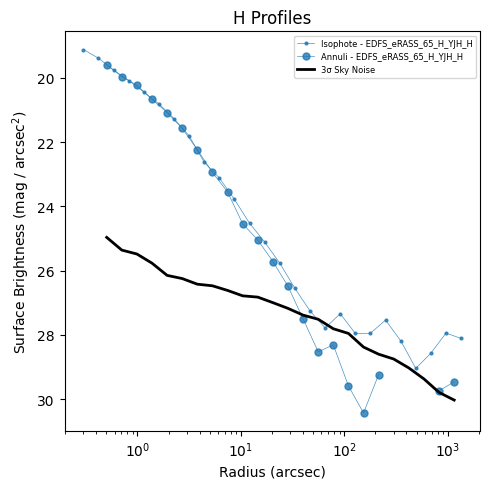

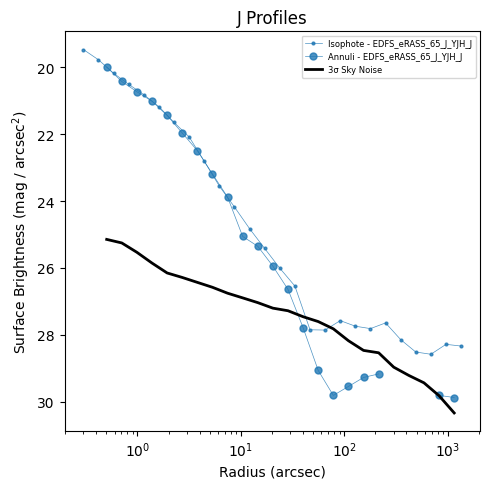

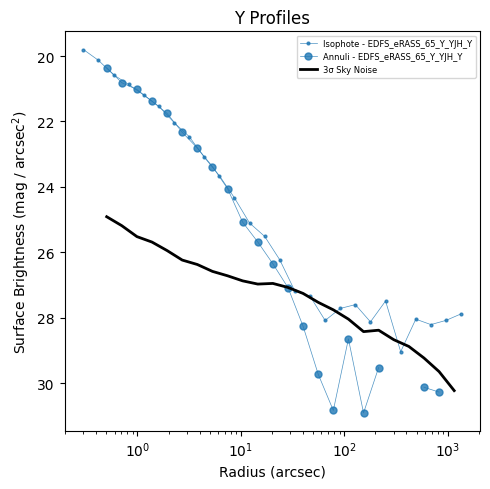

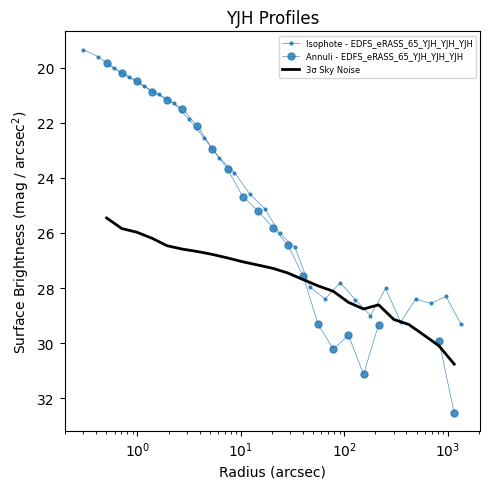

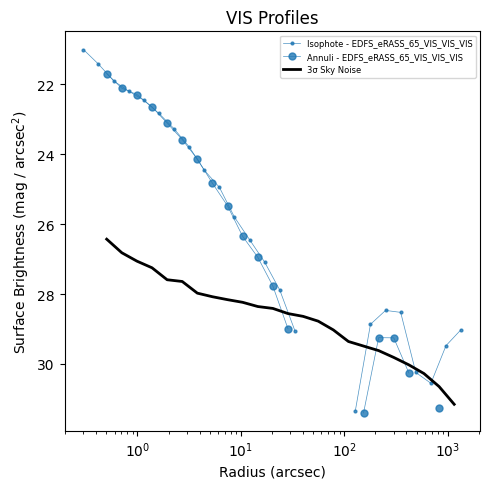

In [44]:
table = pd.read_csv("/home/ppztk1/Erosita/Erosita_EDFS_LargeSample.csv")
cluster_id = 'EDFS_eRASS_65'
cluster_info = table[table.Label_ID == cluster_id].reset_index(drop=True)

outdir = Path(f'/home/ppztk1/Erosita/Outputs_Clusters/')
plotdir = outdir / cluster_id

h_profiles = load_profiles_real_clusters(
    outdir=Path(outdir),
    cluster_id=cluster_id,
    filter='H',
    mask_filter=['YJH'],
    profile_filter='H',
)

j_profiles = load_profiles_real_clusters(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='J',
    mask_filter=['YJH'],
    profile_filter='J',
)

y_profiles = load_profiles_real_clusters(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='Y',
    mask_filter=['YJH'],
    profile_filter='Y',
)

yjh_profiles = load_profiles_real_clusters(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='YJH',
    mask_filter=['YJH'],
    profile_filter='YJH',
 )

vis_profiles = load_profiles_real_clusters(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='VIS',
    mask_filter=['VIS'],
    profile_filter='VIS',
)


profile_vars = {
    'H': h_profiles,
    'J': j_profiles,
    'Y': y_profiles,
    'VIS': vis_profiles,
    'YJH': yjh_profiles,
    'ALL': all_profiles,
}

profile_dicts = {}

profile_dicts = {k: dict(v) for k, v in profile_vars.items()}
print(profile_dicts['VIS'].keys())


plotdir = Path(f'/home/ppztk1/Erosita/Outputs_Clusters/{cluster_id}/')
fluxtype = 'mag'


noise_file_dir= Path('/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/')
noise_profiles = {
    'H': pd.read_csv(noise_file_dir/'Skypatch_bs500_H_noise_measurements.csv'),
    'J': pd.read_csv(noise_file_dir/'Skypatch_bs500_J_noise_measurements.csv'),
    'Y': pd.read_csv(noise_file_dir/'Skypatch_bs500_Y_noise_measurements.csv'),
    'YJH': pd.read_csv(noise_file_dir/'Skypatch_bs500_YJH_noise_measurements.csv'),
    'VIS': pd.read_csv(noise_file_dir/'Skypatch_bs500_VIS_noise_measurements.csv'),
}

# profile sets
all_profiles = {
    'H': h_profiles,
    'J': j_profiles,
    'Y': y_profiles,
    'YJH': yjh_profiles,
    'VIS': vis_profiles,
}

# dictionaries for labels
all_dicts = {
    'H': profile_dicts['H'],
    'J': profile_dicts['J'],
    'Y': profile_dicts['Y'],
    'YJH': profile_dicts['YJH'],
    'VIS': profile_dicts['VIS'],
}

for band in ['H', 'J', 'Y', 'YJH', 'VIS']:
    profiles = all_profiles[band]
    labels = list(all_dicts[band].keys())
    noise_df = noise_profiles[band]

    if band == 'VIS':
        extract_rmax_labels = [f'{cluster_id}_{band}_{band}_{band}']
    else:
        extract_rmax_labels = [f'{cluster_id}_{band}_YJH_{band}']

    style_dict = generate_style_dict_from_labels(
        labels=labels,
        color_by='mask_prefix',
        linestyle_by='mask_prefix',
        marker_by='other_prefix',
        label_format="{prefix}-{mask_filter}-{mask_prefix}-{profile_filter}-{other_prefix}",
    )

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    plot_sb_profiles(
        profiles=profiles,
        # style_dict=style_dict,
        specific_labels=labels,
        rad_output_unit='arcsec',
        ax=ax,
        fluxtype=fluxtype,
        ylog=False,
        noise_profile=noise_df,
        extract_rmax=True,
        extract_rmax_labels= extract_rmax_labels 
        
    )

    # Noise profile in mag
    if fluxtype == 'mag':
        noise = 23.9 - 2.5 * np.log10(3 * noise_df['MAD_Median_Clipped_Flux'])
    else:
        noise = (3 * (noise_df['MAD_Median_Clipped_Flux']))
        ax.set_ylim(-0.1, 1)
        # ax.set_xlim(50, )
    ax.plot(noise_df['SMA_annulus_centre_arcsec'], noise, c='k', lw=2, label='3σ Sky Noise')

    ax.set_title(f"{band} Profiles", fontsize=12)
    ax.legend(loc='upper right' , fontsize=6)
    plt.tight_layout()
    # plt.savefig(plotdir/f"{cluster_id}_{band}_dr225_profiles_SB.pdf")
    plt.show()
    


 BCG r_e = 18.62 kpc
ICL r_e = 499.99 kpc


/tmp/ipykernel_3072957/98245816.py:103: RuntimeWarning: invalid value encountered in log10
  magnitudes = 23.9 - 2.5*np.log10(y)


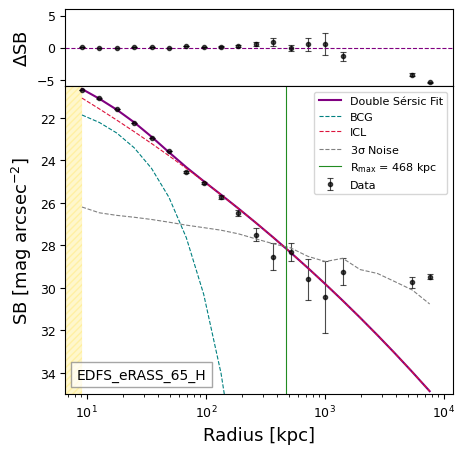

[[Model]]
    Model(double_sersic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 2023
    # data points      = 21
    # variables        = 6
    chi-square         = 2.8120e+08
    reduced chi-square = 18746690.7
    Akaike info crit   = 356.611167
    Bayesian info crit = 362.878301
    R-squared          = 0.99905184
[[Variables]]
    I_e1:  2.79673666 +/- 37.6223567 (1345.22%) (init = 8.537534)
    r_e1:  2.82925891 +/- 7.46360311 (263.80%) (init = 2)
    n1:    1.00000001 +/- 12.5023092 (1250.23%) (init = 4)
    I_e2:  0.01793427 +/- 0.63504022 (3540.93%) (init = 0.03609232)
    r_e2:  75.9890280 +/- 1443.91133 (1900.16%) (init = 15.19817)
    n2:    11.1789104 +/- 111.434097 (996.82%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(I_e2, r_e2) = -0.9980
    C(I_e1, n1)   = -0.9009
    C(I_e1, n2)   = -0.7401
    C(r_e1, n2)   = +0.6669
    C(n1, n2)     = +0.6402
    C(I_e2, n2)   = -0.5677
    C(r_e2, n2)   = +0.5463
    C(r_

/tmp/ipykernel_3072957/98245816.py:103: RuntimeWarning: invalid value encountered in log10
  magnitudes = 23.9 - 2.5*np.log10(y)


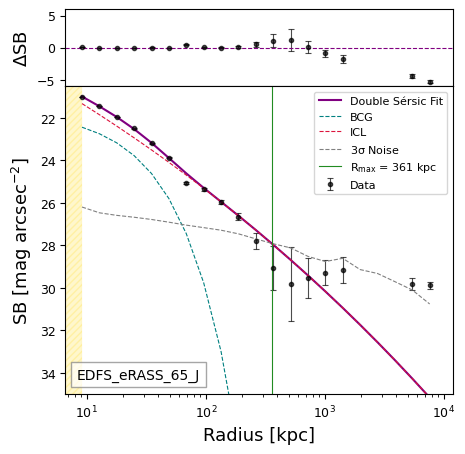

[[Model]]
    Model(double_sersic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1510
    # data points      = 21
    # variables        = 6
    chi-square         = 1.3683e+08
    reduced chi-square = 9122033.49
    Akaike info crit   = 341.484352
    Bayesian info crit = 347.751487
    R-squared          = 0.99944276
[[Variables]]
    I_e1:  1.47794212 +/- 14.4785561 (979.64%) (init = 5.96259)
    r_e1:  3.25994060 +/- 9.40776625 (288.59%) (init = 2)
    n1:    1.00000000 +/- 10.6045417 (1060.45%) (init = 4)
    I_e2:  0.01303682 +/- 0.50583687 (3880.06%) (init = 0.02782564)
    r_e2:  75.9898915 +/- 1551.37913 (2041.56%) (init = 15.19817)
    n2:    11.9613001 +/- 93.1188426 (778.50%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(I_e2, r_e2) = -0.9984
    C(I_e1, n1)   = -0.8318
    C(I_e2, n2)   = -0.7606
    C(r_e2, n2)   = +0.7547
    C(r_e1, n2)   = +0.6176
    C(r_e1, I_e2) = -0.5066
    C(r_e1, r_e2) = +0.4706
    C(n1, 

/tmp/ipykernel_3072957/98245816.py:103: RuntimeWarning: invalid value encountered in log10
  magnitudes = 23.9 - 2.5*np.log10(y)


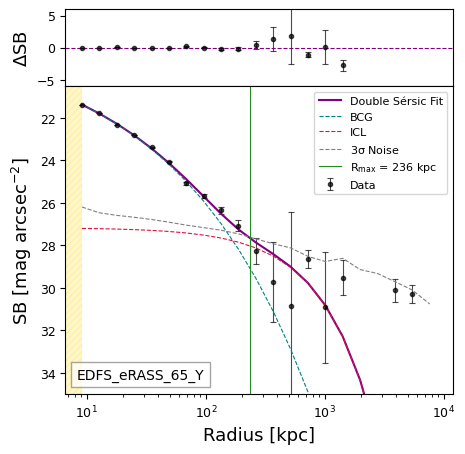

[[Model]]
    Model(double_sersic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 178
    # data points      = 21
    # variables        = 6
    chi-square         = 25579866.8
    reduced chi-square = 1705324.45
    Akaike info crit   = 306.268668
    Bayesian info crit = 312.535803
    R-squared          = 0.99902347
[[Variables]]
    I_e1:  1.35333839 +/- 4.83756494 (357.45%) (init = 4.24512)
    r_e1:  5.61074835 +/- 12.9214697 (230.30%) (init = 2)
    n1:    2.58832104 +/- 5.18410677 (200.29%) (init = 4)
    I_e2:  0.00933015 +/- 0.07846242 (840.96%) (init = 0.0180592)
    r_e2:  75.9908729 +/- 3.28988233 (4.33%) (init = 15.19817)
    n2:    1.00000001 +/- 35.3240744 (3532.41%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(I_e1, r_e1) = -0.9962
    C(I_e1, n1)   = -0.9736
    C(r_e1, n1)   = +0.9539
    C(I_e2, r_e2) = +0.8930
    C(r_e1, n2)   = +0.8024
    C(I_e1, n2)   = -0.7681
    C(n1, n2)     = +0.6894
    C(I_e2, n2) 

/tmp/ipykernel_3072957/98245816.py:103: RuntimeWarning: invalid value encountered in log10
  magnitudes = 23.9 - 2.5*np.log10(y)


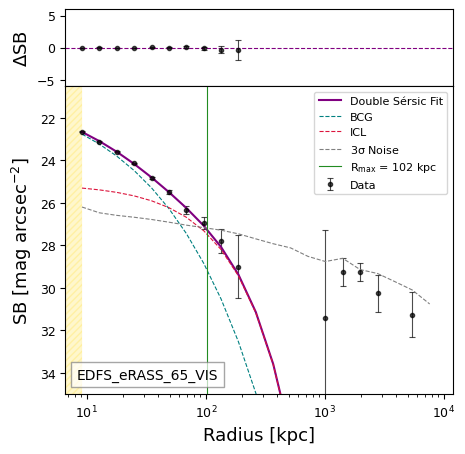

[[Model]]
    Model(double_sersic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 408
    # data points      = 21
    # variables        = 6
    chi-square         = 3140105.84
    reduced chi-square = 209340.389
    Akaike info crit   = 262.220137
    Bayesian info crit = 268.487272
    R-squared          = 0.99972869
[[Variables]]
    I_e1:  0.87253996 +/- 17.9910165 (2061.91%) (init = 1.341416)
    r_e1:  3.09306910 +/- 63.3270230 (2047.38%) (init = 2)
    n1:    1.85446077 +/- 22.9916466 (1239.80%) (init = 4)
    I_e2:  0.06313133 +/- 3.18062906 (5038.12%) (init = 0.007255012)
    r_e2:  11.8999804 +/- 172.027794 (1445.61%) (init = 15.19817)
    n2:    1.00000050 +/- 65.9709451 (6597.09%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(r_e1, I_e2) = -0.9977
    C(I_e1, r_e1) = -0.9968
    C(I_e2, r_e2) = -0.9959
    C(I_e1, I_e2) = +0.9950
    C(I_e1, n1)   = -0.9936
    C(r_e1, r_e2) = +0.9894
    C(I_e1, r_e2) = -0.9837
    C(

/tmp/ipykernel_3072957/98245816.py:103: RuntimeWarning: invalid value encountered in log10
  magnitudes = 23.9 - 2.5*np.log10(y)


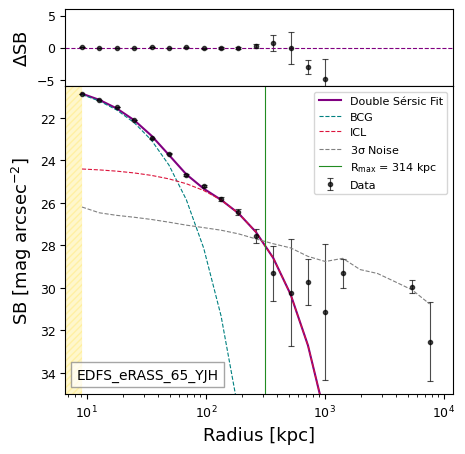

[[Model]]
    Model(double_sersic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7622
    # data points      = 21
    # variables        = 6
    chi-square         = 12265139.1
    reduced chi-square = 817675.939
    Akaike info crit   = 290.832732
    Bayesian info crit = 297.099867
    R-squared          = 0.99879268
[[Variables]]
    I_e1:  6.02217613 +/- 2.02439686 (33.62%) (init = 9.197124)
    r_e1:  3.30388783 +/- 1.32729425 (40.17%) (init = 2)
    n1:    1.00000000 +/- 14.8467001 (1484.67%) (init = 4)
    I_e2:  0.13114546 +/- 0.22788168 (173.76%) (init = 0.03442006)
    r_e2:  23.6072304 +/- 22.9388279 (97.17%) (init = 15.19817)
    n2:    1.00013842 +/- 3.75474277 (375.42%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(I_e1, n1)   = +0.9321
    C(I_e1, r_e1) = -0.8824
    C(r_e1, n1)   = -0.8790
    C(I_e2, r_e2) = -0.8724
    C(r_e1, n2)   = -0.8247
    C(n1, n2)     = +0.6239
    C(I_e1, n2)   = +0.5164
    C(I_e1, r_

In [45]:

bands = ['H' , 'J', 'Y', 'VIS', 'YJH']

for band in bands:
    image_band = band
    mask_band = 'YJH' if band in ['H' , 'J', 'Y','YJH'] else 'VIS'
    profile_band = image_band
    cluster_id = 'EDFS_eRASS_65'
    
    # def analysis_plots_pipeline(clusterid, redshift, image_band, mask_band, profile_band=None):
    #     if profile_band is None:
    #         profile_band = image_band
    
            
    label = f'{cluster_id}_{image_band}_{mask_band}_{profile_band}'
    prof = profile_dicts[f'{image_band}'][label]
    
    noiserad, noiseflux = prof['SMA_annulus_centre_noise'], prof['MAD_median_clipped_flux_noise']
    rad, flux = prof['SMA_annulus_centre'], prof['Median_flux_annulus']
    results, Rmax = fit_sersic_profile(rad, flux, noise_prof, model_type='Double', label=f'{cluster_id}_{image_band}', z=0.58, rad_unit='kpc', output_dir=plotdir)
